# F2-statistics and population structure heatmap (AADR dataset)

This notebook reproduces the R/`admixtools` workflow from the *Fixation index $F_{st}$* slide, adapted to run on **Google Colab**.

It will:
1. Install `conda` on Colab via `condacolab`
2. Install R and the required R packages (`admixtools`, `tidyverse`, `pheatmap`) on the fly
3. Mount your Google Drive and move into the AADR data folder
4. Compute pairwise **F2-statistics** with `admixtools::extract_f2()` / `read_f2()`
5. Plot the pairwise F2 matrix as a clustered heatmap, in a **landscape** layout

> **Note on runtime:** Step 2 (`condacolab.install()`) automatically **restarts the Colab runtime**. This is expected — after it restarts, just continue running the notebook from the next cell onward (you do not need to re-run the `condacolab.install()` cell itself).

## 1. Install conda (condacolab)

In [1]:
!pip install -q condacolab
import condacolab
condacolab.install()



📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

✨🍰✨ Everything looks OK!


The cell above restarts the runtime automatically. Once it has restarted, continue by running the cell below to confirm conda is working, then proceed with the rest of the notebook.

In [2]:
import condacolab
condacolab.check()


✨🍰✨ Everything looks OK!


## 2. Install required R/Python packages

In [3]:
# Core R + dependencies needed by the admixtools R package, via conda-forge
!mamba install -y -c conda-forge \
    r-rlang \
    r-tidyverse \
    r-devtools \
    r-data.table \
    r-rcpp \
    r-rcpparmadillo \
    r-igraph \
    r-matrix \
    r-pgenlibr \
    r-remotes \
    r-tidyverse \
    r-pheatmap \
    r-future \
    r-future.apply \
    r-furrr \
    r-pheatmap

conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache
[+] 0.0s
[+] 0.0s

Pinned packages:

  - python=3.13

Pinned packages:

  - python_abi[version="=3.13",build="*cp313*"]

Pinned packages:

  - cuda-version*.*

Pinned packages:

  - python=3.13


Transaction

  Prefix: /usr/local

  All requested packages already installed


Transaction starting
[+] 0.0s

Transaction finished



In [4]:
# in case R magic is not installed
# Uninstall all rpy2-related packages
!pip uninstall rpy2 rpy2-rinterface rpy2-robjects -y

# Install a known-working version
!pip install rpy2==3.5.1

Found existing installation: rpy2 3.5.1
Uninstalling rpy2-3.5.1:
  Successfully uninstalled rpy2-3.5.1
  Using cached rpy2-3.5.1-cp313-cp313-linux_x86_64.whl


In [5]:
%load_ext rpy2.ipython

In [6]:
%%R
library(rlang)
packageVersion("rlang")

[1] ‘1.3.0’


In [8]:
%%R
# admixtools (ADMIXTOOLS 2) is not on conda-forge/CRAN, so install it from GitHub
if (!requireNamespace("admixtools", quietly = TRUE)) {
  devtools::install_github("uqrmaie1/admixtools", upgrade = "never")
}

R[write to console]: Downloading GitHub repo uqrmaie1/admixtools@HEAD

R[write to console]: Installing 8 packages: iterators, foreach, quadprog, lobstr, doParallel, data.tree, cubelyr, abind

R[write to console]: Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/iterators_1.0.14.tar.gz'

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/foreach_1.5.2.tar.gz'

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/quadprog_1.5-8.tar.gz'

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/lobstr_1.2.2.tar.gz'

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/doParallel_1.0.17.tar.gz'

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/data.tree_1.2.0.tar.gz'

R[write to console]: trying URL 'https://cloud.r-project.org/src/contrib/cubelyr_1.0.2.tar.gz'

R[write to console]: t

── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/RtmpfJEKtB/remotes16ee50419db7/uqrmaie1-admixtools-472d04e/DESCRIPTION’ ... OK
* preparing ‘admixtools’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘admixtools_2.0.10.tar.gz’



R[write to console]: Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [9]:
%%R

library("admixtools")
library("tidyverse")
library("pheatmap")

cat("admixtools version:", as.character(packageVersion("admixtools")), "\n")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()      masks stats::filter()
✖ purrr::flatten()     masks rlang::flatten()
✖ purrr::flatten_chr() masks rlang::flatten_chr()
✖ purrr::flatten_dbl() masks rlang::flatten_dbl()
✖ purrr::flatten_int() masks rlang::flatten_int()
✖ purrr::flatten_lgl() masks rlang::flatten_lgl()
✖ purrr::flatten_raw() masks rlang::flatten_raw()
✖ purrr::invoke()      masks rlang::invoke()
✖ dplyr::lag()         masks stats::lag()
✖ purrr::splice()      masks rlang::splice()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
admixtools version: 2.0.10 


In [10]:
%%R
library(admixtools)
packageVersion("admixtools")

[1] ‘2.0.10’


## 3. Mount Google Drive and move into the AADR folder

In [11]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [12]:
import os

aadr_dir = '/content/drive/MyDrive/PopGen_PopStructure/AADR'
os.chdir(aadr_dir)
print("Working directory:", os.getcwd())
print(os.listdir('.'))


Working directory: /content/drive/MyDrive/PopGen_PopStructure/AADR
['AADR.geno', 'AADR.ind', 'AADR.snp', 'f2_AADR']


## 4. Compute pairwise F2-statistics

This follows the slide's R code directly: `extract_f2()` reads the AADR genotype files (expected as `AADR.geno` / `AADR.ind` / `AADR.snp`, or PLINK-format equivalents, in the current working directory) and precomputes pairwise F2-statistics into the `f2_AADR` folder.

> **Tip:** On the full AADR dataset this step can be slow/memory-heavy. If it's too slow on Colab, restrict to a subset of populations with `extract_f2("AADR", outdir = "f2_AADR", pops = my_pops)`.

In [13]:
%%R
# Confirm R's working directory matches the Python one (rpy2 shares the process,
# but let's be explicit)
cat("R working directory:", getwd(), "\n")

# Extract F2 statistics (skips recomputation if already extracted)
if (!dir.exists("f2_AADR")) {
  admixtools::extract_f2("AADR", outdir = "f2_AADR")
}

f2_aadr <- read_f2("f2_AADR")

# Fst computation
fst_aadr <- fst(f2_aadr)
fst_aadr

R working directory: /content/drive/MyDrive/PopGen_PopStructure/AADR 
# A tibble: 528 × 4
   pop1  pop2          est       se
   <chr> <chr>       <dbl>    <dbl>
 1 AA    Ami       0.0494  0.000388
 2 AA    Atayal    0.0546  0.000421
 3 AA    BedouinB  0.0314  0.000303
 4 AA    Biaka     0.0126  0.000151
 5 AA    Brahui    0.0290  0.000290
 6 AA    Chukchi   0.0496  0.000370
 7 AA    Datog     0.00767 0.000225
 8 AA    Esan      0.00340 0.000103
 9 AA    Georgian  0.0313  0.000300
10 AA    GujaratiD 0.0310  0.000335
# ℹ 518 more rows
# ℹ Use `print(n = ...)` to see more rows


## 5. Build the pairwise F2 matrix and plot the heatmap (landscape layout)

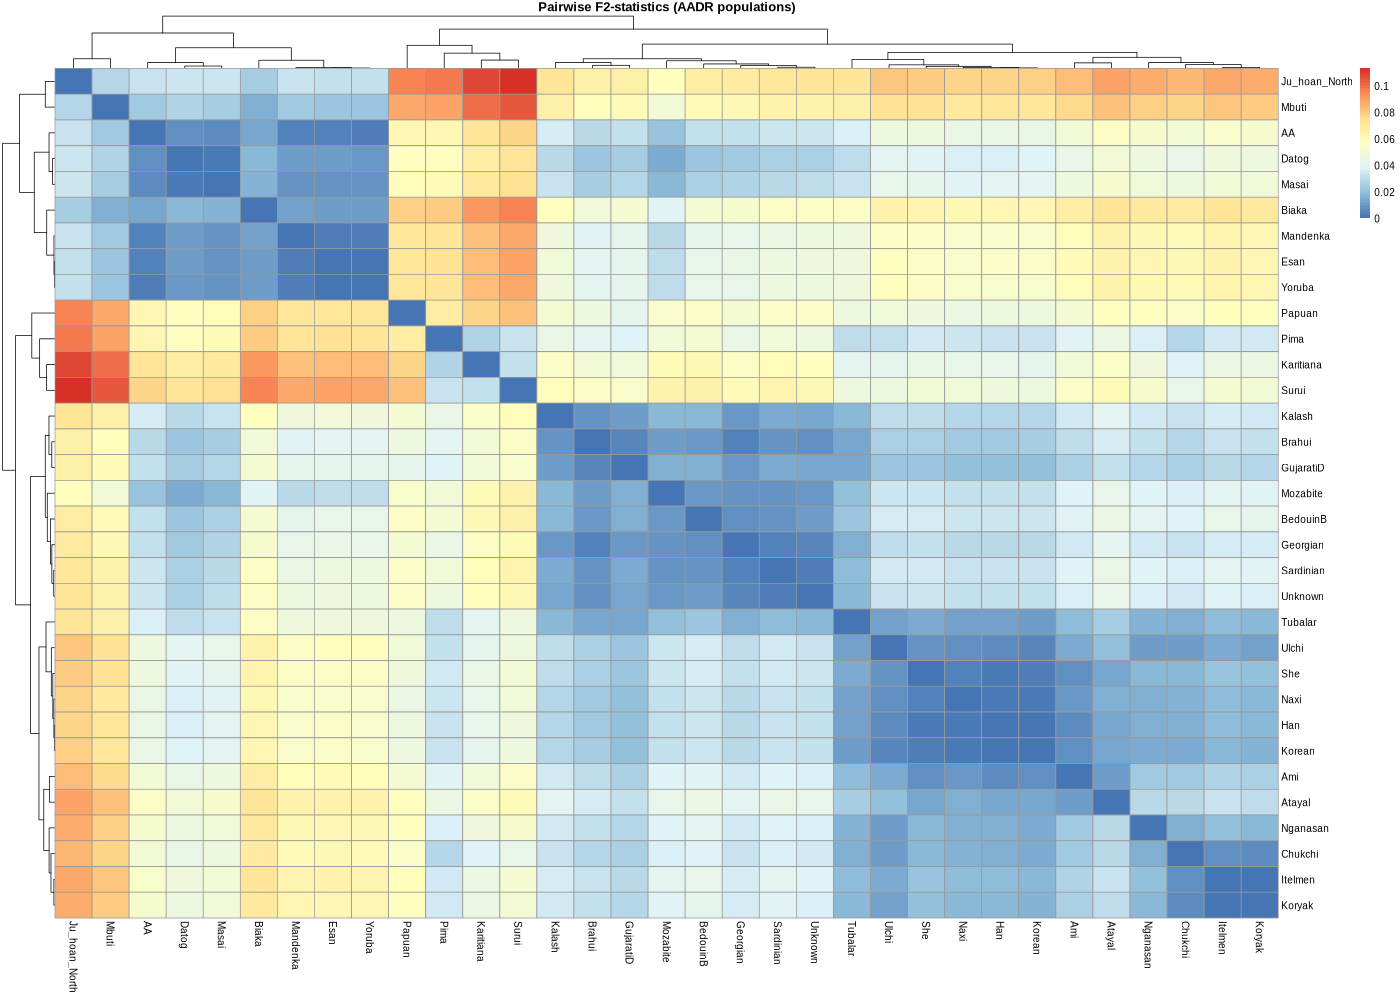

In [14]:
%%R -w 1400 -h 1000 -u px

library("pheatmap")

mat <- f2(f2_aadr, unique_only = FALSE) %>%
  dplyr::select(-se) %>%
  tidyr::pivot_wider(
    names_from = pop2,
    values_from = est
  ) %>%
  tibble::column_to_rownames("pop1") %>%
  as.matrix()

pheatmap(
  mat,
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  main = "Pairwise F2-statistics (AADR populations)"
)

---
### Notes
- The `-w 1400 -h 1000 -u px` on the final `%%R` cell sets a wide (landscape) figure size for the heatmap; adjust these values to taste.
- If you re-run the notebook later, the `if (!dir.exists("f2_AADR"))` check avoids recomputing F2-statistics from scratch.
- If `extract_f2()` fails to find your genotype files, double-check that `AADR.geno`, `AADR.ind`, and `AADR.snp` (or equivalent PLINK files) are directly inside `/content/drive/MyDrive/PopGen_PopStructure/AADR`.

## 6. F3-outgroup statistic for the "Unknown" population

We use the already-extracted AADR F2-statistics to compute an **outgroup F3-statistic**: `f3(pop1 = Mbuti, pop2 = Unknown, pop3 = <every population in the panel>)`.

Using Mbuti as an outgroup, this measures how much shared genetic drift the "Unknown" population has with each other population since their divergence from Mbuti — populations that split more recently from "Unknown" (i.e. are more closely related to it) will have a **higher** F3 value.

Populations are sorted by F3 value and plotted with error bars (±3 standard errors), reproducing the slide's `viz_outgroup_f3()` plot.

In [42]:
%%R

# =============================================================
# F3-outgroup statistic for an Unknown population
# =============================================================

# Load required libraries
library("admixtools")
library("tidyverse")

# 1. Extract F2 statistics from the AADR dataset
#    This computes all pairwise F2 distances and saves them to the "f2_AADR" directory.
# Extract F2 statistics (skips recomputation if already extracted)
if (!dir.exists("f2_AADR")) {
  admixtools::extract_f2("AADR", outdir = "f2_AADR")
}

# 2. Read the F2 data back into R
f2_aadr <- read_f2("f2_AADR")
ind <- read.table("AADR.ind",header = FALSE,stringsAsFactors = FALSE)
colnames(ind) <- c("ID", "sex", "pop")

# 3. Compute Fst from the F2 data
#    (Note: This line is present in the slide but the result `fst_aadr` is not used later in the code)
fst_aadr <- fst(f2_aadr)

# 4. Compute the F3-outgroup statistic
#    pop1 = "Mbuti" (outgroup)
#    pop2 = "Unknown" (target population)
#    pop3 = all other populations in the dataset
f3_aadr <- f3(f2_aadr, pop1 = "Mbuti", pop2 = "Unknown", pop3 = unique(ind$pop)) %>%
  arrange(est)

# 5. Define a custom visualization function for the F3 results
viz_outgroup_f3 <- function(f3_res) {
  f3_res %>%
    mutate(pop3 = fct_reorder(pop3, est)) %>%
    ggplot(aes(x = pop3, y = est, ymin = est - 3 * se, ymax = est + 3 * se)) +
    geom_point() +
    geom_errorbar() +
    coord_flip() +
    theme_bw(15) +
    xlab(NULL) +
    ylab("f3")
}

# 6. Run the visualization
p <- viz_outgroup_f3(f3_aadr)
ggsave("F3_outgroup.png",plot = p, width = 10, height = 6, units = "in", dpi = 300)

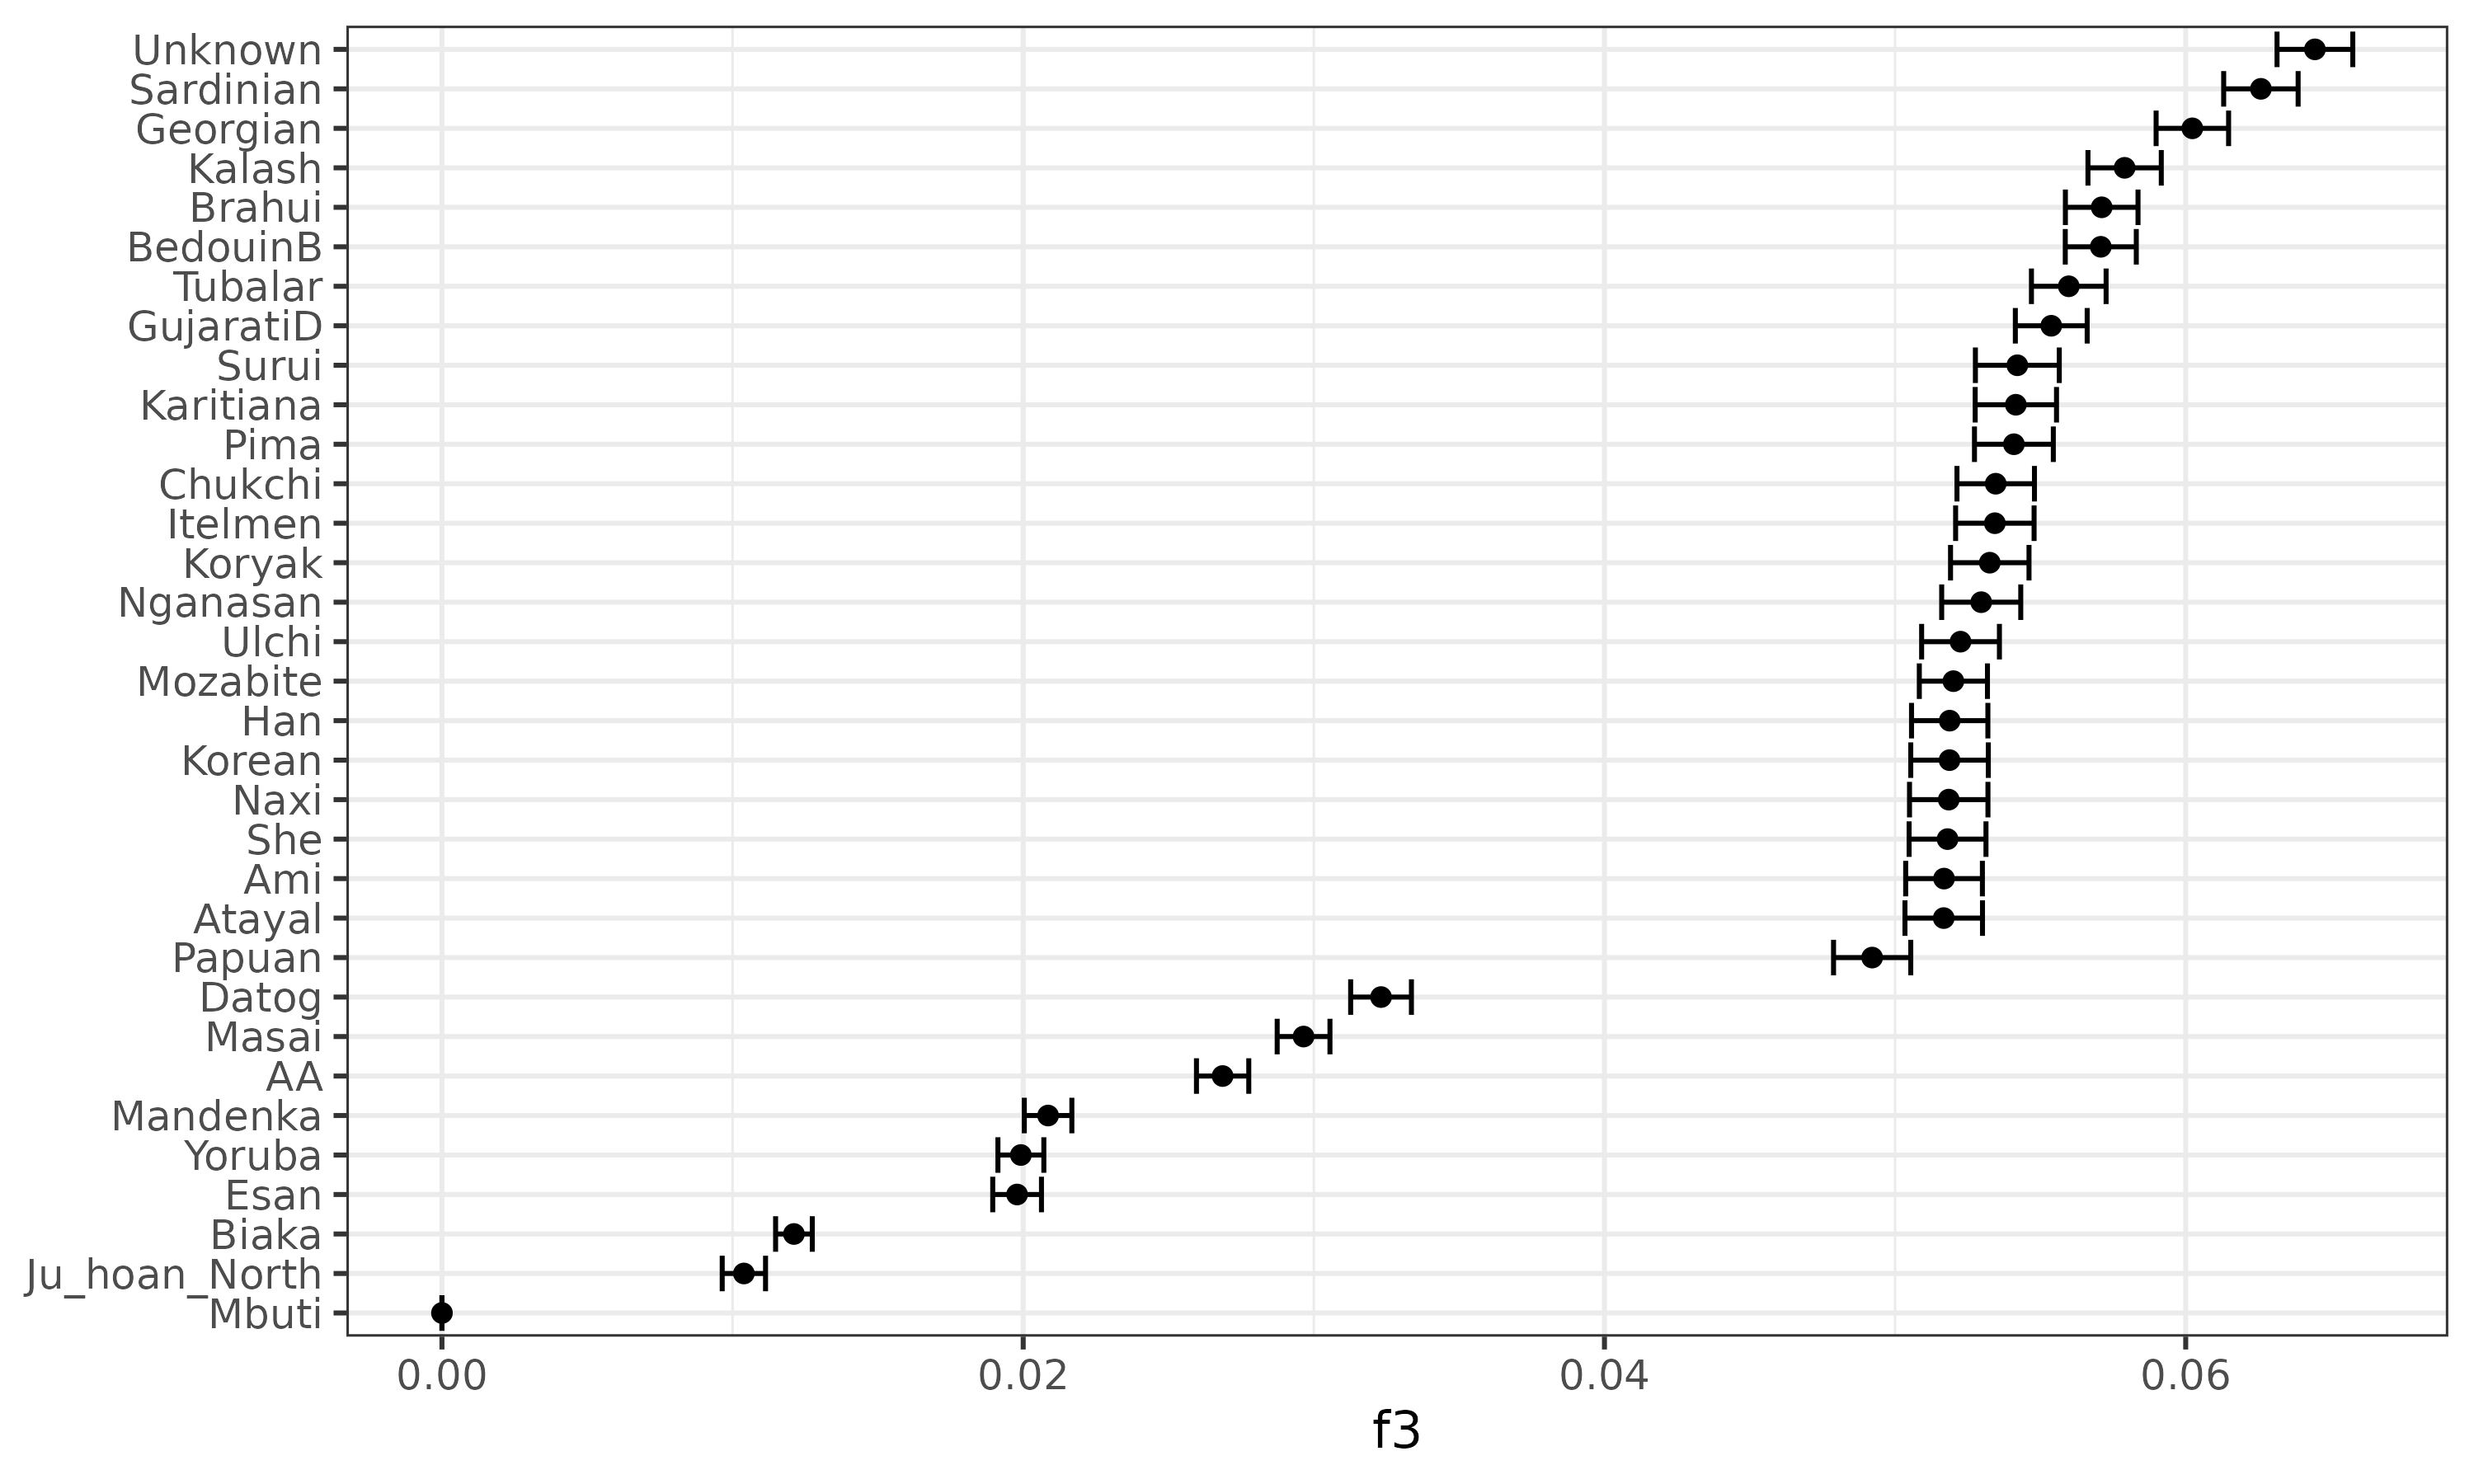

In [43]:
from IPython.display import Image, display
display(Image(filename="F3_outgroup.png"))

In [44]:
# ----- 2. Run nbconvert -------------------------------------------
# Convert the notebook on disk to a standalone HTML file.
!jupyter nbconvert --to html /content/drive/MyDrive/PopGen_PopStructure/F2_statistics_AADR_heatmap.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/PopGen_PopStructure/F2_statistics_AADR_heatmap.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 722602 bytes to /content/drive/MyDrive/PopGen_PopStructure/F2_statistics_AADR_heatmap.html
